# Flow Sample Diagnostics

Focused notebook for cached-sample diagnostics using hierarchical cache layout from [scr]_tf_analysis.py.

In [1]:
import json
import os
import sys
from os.path import join

# Add parent directory (arch/) to path so we can import sibling modules
# Handle both cases: notebook run from diagnostics/ or from arch/
current_dir = os.getcwd()
if 'diagnostics' in current_dir:
    arch_dir = os.path.dirname(current_dir)
else:
    arch_dir = current_dir

if arch_dir not in sys.path:
    sys.path.insert(0, arch_dir)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import config
from utils import density_contour, img_to_gal_axis, make_corner_plot, make_g_contour

In [27]:
# Configure these paths and identifiers for your run
cache_root = '/ocean/projects/phy250048p/shared/cache'
fig_root = '/ocean/projects/phy250048p/shared/figures'
sample_csv = '/ocean/projects/phy250048p/shared/samples/samples_valid_1m.csv'

model_name = 'CNN-CNN-flow'
dataset_name = 'valid_1m'
os.makedirs(join(fig_root, model_name), exist_ok=True)
partitions = [f'part{i}of10' for i in range(2)]

# 0 -> mode 1 (no TF prior), 1 -> mode 2 (with TF prior)
mode_index = 0
snr_tolerance = 1.0
vcirc_idx = 5

In [3]:
data_types = ['sample', 'log_prob', 'snr', 'truth', 'map_estimates', 'mean_estimates', 'meta']

def cache_path(data_type, partition, ext='npy'):
    if data_type not in data_types:
        raise ValueError(f'Unsupported data type: {data_type}')
    return join(cache_root, model_name, dataset_name, data_type, f'{partition}.{ext}')

def load_partition(partition):
    sample_path = cache_path('sample', partition)
    log_prob_path = cache_path('log_prob', partition)
    snr_path = cache_path('snr', partition)
    truth_path = cache_path('truth', partition)
    map_path = cache_path('map_estimates', partition)
    mean_path = cache_path('mean_estimates', partition)
    meta_path = cache_path('meta', partition, ext='json')

    required = [sample_path, log_prob_path, snr_path, truth_path, map_path, mean_path, meta_path]
    missing = [p for p in required if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError('Missing hierarchical cache files for partition '
                                f"{partition}: {missing}")

    with open(meta_path, 'r', encoding='ascii') as fp:
        meta = json.load(fp)

    return {
        'partition': partition,
        'sample': np.load(sample_path),
        'log_prob': np.load(log_prob_path),
        'snr': np.load(snr_path),
        'truth': np.load(truth_path),
        'map_estimates': np.load(map_path),
        'mean_estimates': np.load(mean_path),
        'meta': meta,
    }

In [4]:
parts = [load_partition(p) for p in partitions]

samples = np.concatenate([p['sample'] for p in parts], axis=1)
log_probs = np.concatenate([p['log_prob'] for p in parts], axis=1)
snrs = np.concatenate([p['snr'] for p in parts], axis=0)
truths = np.concatenate([p['truth'] for p in parts], axis=0)
map_estimates = np.concatenate([p['map_estimates'] for p in parts], axis=1)
mean_estimates = np.concatenate([p['mean_estimates'] for p in parts], axis=1)

ngals = truths.shape[0]

assert samples.shape[1] == ngals
assert log_probs.shape[1] == ngals
assert snrs.shape[0] == ngals
assert map_estimates.shape[1] == ngals
assert mean_estimates.shape[1] == ngals

print('samples', samples.shape)
print('log_probs', log_probs.shape)
print('snrs', snrs.shape)
print('truths', truths.shape)
print('map_estimates', map_estimates.shape)
print('mean_estimates', mean_estimates.shape)

samples (2, 20000, 10000, 8)
log_probs (2, 20000, 10000)
snrs (20000,)
truths (20000, 8)
map_estimates (2, 20000, 8)
mean_estimates (2, 20000, 3, 8)


In [21]:
print(truths[:10, 2])

[ 2.8203022  -1.4469233  -2.3604987  -0.29672337  1.3423712  -2.6480799
  1.2794764   0.9066951  -2.960417   -1.7771676 ]


In [28]:
sample_table = pd.read_csv(sample_csv)
theta = np.array(sample_table['theta_int'])[:ngals]
if theta.shape[0] != ngals:
    raise ValueError(f'theta length mismatch: {theta.shape[0]} vs {ngals}')

g1_true = truths[:, 0]
g2_true = truths[:, 1]
vcirc_true = truths[:, vcirc_idx]

g1_pred = map_estimates[mode_index, :, 0]
g2_pred = map_estimates[mode_index, :, 1]
vcirc_pred = map_estimates[mode_index, :, vcirc_idx]

g1_diff = g1_pred - g1_true
g2_diff = g2_pred - g2_true
vcirc_diff = vcirc_pred - vcirc_true

gp_true, gc_true = img_to_gal_axis(g1_true, g2_true, theta)
gp_pred, gc_pred = img_to_gal_axis(g1_pred, g2_pred, theta)
gp_diff = gp_pred - gp_true
gc_diff = gc_pred - gc_true

In [7]:
from plots import ParameterContourPlotter

plotter = ParameterContourPlotter(
    model_name=model_name,
    true=truths,
    pred=map_estimates[0],
    pred_tf=map_estimates[1],
    snr=snrs,
    feature_names=config.train['feature_names'],
)

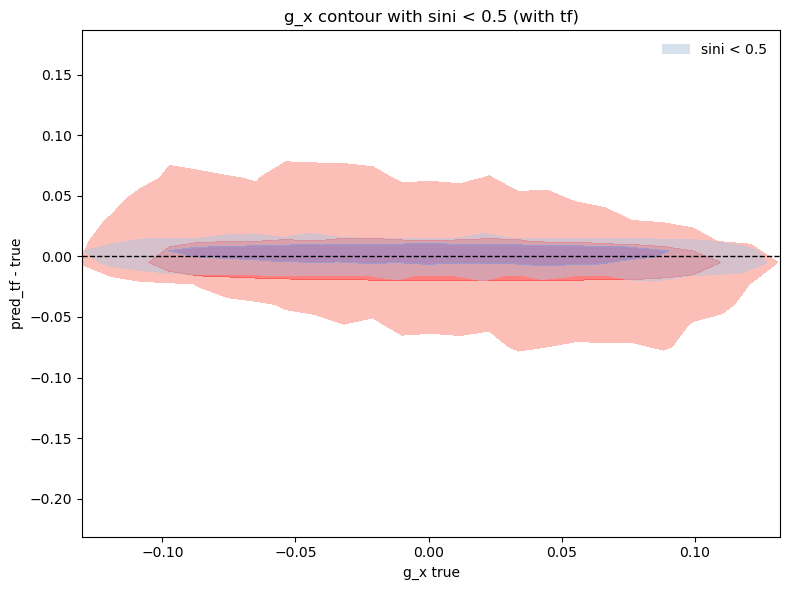

In [33]:
_, _, out_masked = plotter.plot(
    param='gx',
    mask_param='sini',
    masking_value=0.5,
    flip_mask=True,
    use_tf=True,
    nbins=25,
)

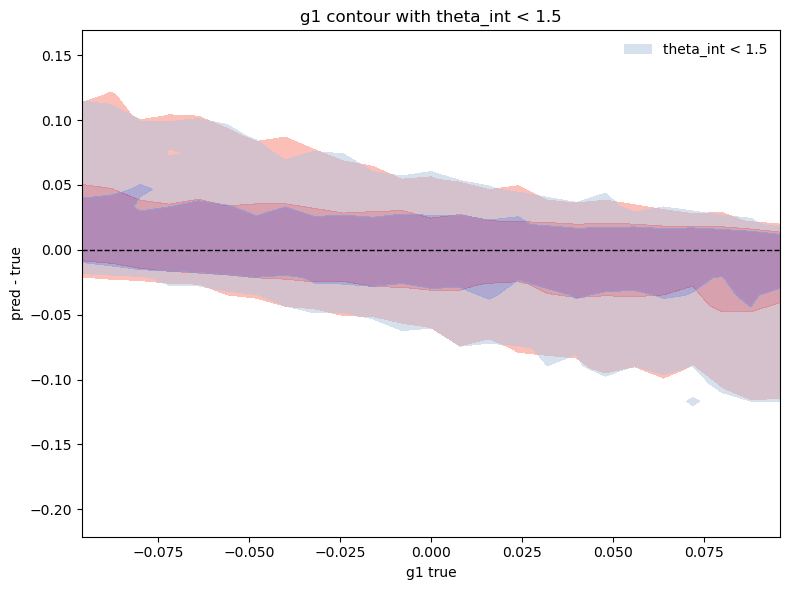

In [11]:
_, _, out_masked = plotter.plot(
    param='g1',
    mask_param='theta_int',
    masking_value=1.5,
    flip_mask=True,
    use_tf=False,
    nbins=25,
)

In [11]:
snr_target = 10
snr_idx = np.where(np.abs(snrs - snr_target) < snr_tolerance)[0]
print(f'Candidates near SNR={snr_target}:', snr_idx.shape[0])

n_examples = min(5, snr_idx.shape[0])
for i in range(n_examples):
    idx = snr_idx[i]
    print(vcirc_pred[idx], truths[idx, vcirc_idx])
    mode_samples = [samples[0, idx], samples[1, idx]]
    fig, _, _ = make_corner_plot(
        mode_samples,
        truth=truths[idx],
        labels=config.train['feature_names'],
        sample_labels=['no TF prior', 'with TF prior'],
        suptitle=f'Galaxy {idx}, SNR={snrs[idx]:.2f}',
    )
    fig.savefig(join(fig_root, model_name, f'corner_snr_{int(snr_target)}_{i}.png'), dpi=300)
    # fig.savefig(join(fig_root, model_name, f'corner_vcirc_diff_gt_100_{i}.png'), dpi=300)
    plt.close(fig)

Candidates near SNR=10: 20
436.3178405761719 420.75388
Removed no burn in
Removed no burn in
481.6712341308594 495.7267
Removed no burn in
Removed no burn in
270.1263122558594 273.738
Removed no burn in
Removed no burn in
158.5706787109375 162.63028
Removed no burn in
Removed no burn in
434.3358459472656 446.28442
Removed no burn in
Removed no burn in


In [25]:
sini = np.array(sample_table['sini'])[:ngals]
# sini = np.sin(np.array(sample_table['i'])[:ngals])
sini_mask = sini < 0.5

In [17]:
os.makedirs(join(fig_root, model_name), exist_ok=True)

legend_sini = [
    r'$2\sigma$, $\sin i$ > 0.5',
    r'$1\sigma$, $\sin i$ > 0.5',
    r'$2\sigma$, $\sin i$ < 0.5',
    r'$1\sigma$, $\sin i$ < 0.5',
]

make_g_contour(
    g1_true, g2_true, g1_diff, g2_diff,
    axis='12',
    nbins=25,
    mask=sini_mask,
    anti_mask=True,
    legend_str_list=legend_sini,
    save=True,
    filename=f'g12_contour_sini_split_{mode_index}.png',
    fig_dir=fig_root,
    stem=model_name,
)

make_g_contour(
    gp_true, gc_true, gp_diff, gc_diff,
    axis='pc',
    nbins=25,
    mask=sini_mask,
    anti_mask=True,
    legend_str_list=legend_sini,
    save=True,
    filename=f'gpc_contour_sini_split_{mode_index}.png',
    fig_dir=fig_root,
    stem=model_name,
)

plt.close('all')

In [18]:
os.makedirs(join(fig_root, model_name), exist_ok=True)

legend_snr = [
    r'$2\sigma$, $SNR < 250$',
    r'$1\sigma$, $SNR < 250$',
    r'$2\sigma$, $SNR > 250$',
    r'$1\sigma$, $SNR > 250$',
]
snr_mask = snrs[sini_mask] > 250
g1_true_cut, g2_true_cut = g1_true[sini_mask], g2_true[sini_mask]
g1_diff_cut, g2_diff_cut = g1_diff[sini_mask], g2_diff[sini_mask]
gp_true_cut, gc_true_cut = gp_true[sini_mask], gc_true[sini_mask]
gp_diff_cut, gc_diff_cut = gp_diff[sini_mask], gc_diff[sini_mask]

make_g_contour(
    g1_true_cut, g2_true_cut, g1_diff_cut, g2_diff_cut,
    axis='12',
    nbins=25,
    mask=snr_mask,
    anti_mask=True,
    legend_str_list=legend_snr,
    save=True,
    filename=f'g12_contour_snr_split_sini_cut_{mode_index}.png',
    fig_dir=fig_root,
    stem=model_name,
)

make_g_contour(
    gp_true_cut, gc_true_cut, gp_diff_cut, gc_diff_cut,
    axis='pc',
    nbins=25,
    mask=snr_mask,
    anti_mask=True,
    legend_str_list=legend_snr,
    save=True,
    filename=f'gpc_contour_snr_split_sini_cut_{mode_index}.png',
    fig_dir=fig_root,
    stem=model_name,
)

plt.close('all')

In [23]:
def binned_bias(x_true, x_diff, nbins=20):
    edges = np.linspace(-0.1, 0.1, nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    which = np.searchsorted(edges, x_true) - 1

    mean = np.full(nbins, np.nan, dtype=np.float64)
    err = np.full(nbins, np.nan, dtype=np.float64)

    for i in range(nbins):
        mask = which == i
        if np.any(mask):
            vals = x_diff[mask]
            mean[i] = np.mean(vals)
            err[i] = np.std(vals) / np.sqrt(vals.shape[0])

    return centers, mean, err

c1, m1, e1 = binned_bias(g1_true, g1_diff)
c2, m2, e2 = binned_bias(g2_true, g2_diff)
cp, mp, ep = binned_bias(gp_true, gp_diff)
cx, mx, ex = binned_bias(gc_true, gc_diff)

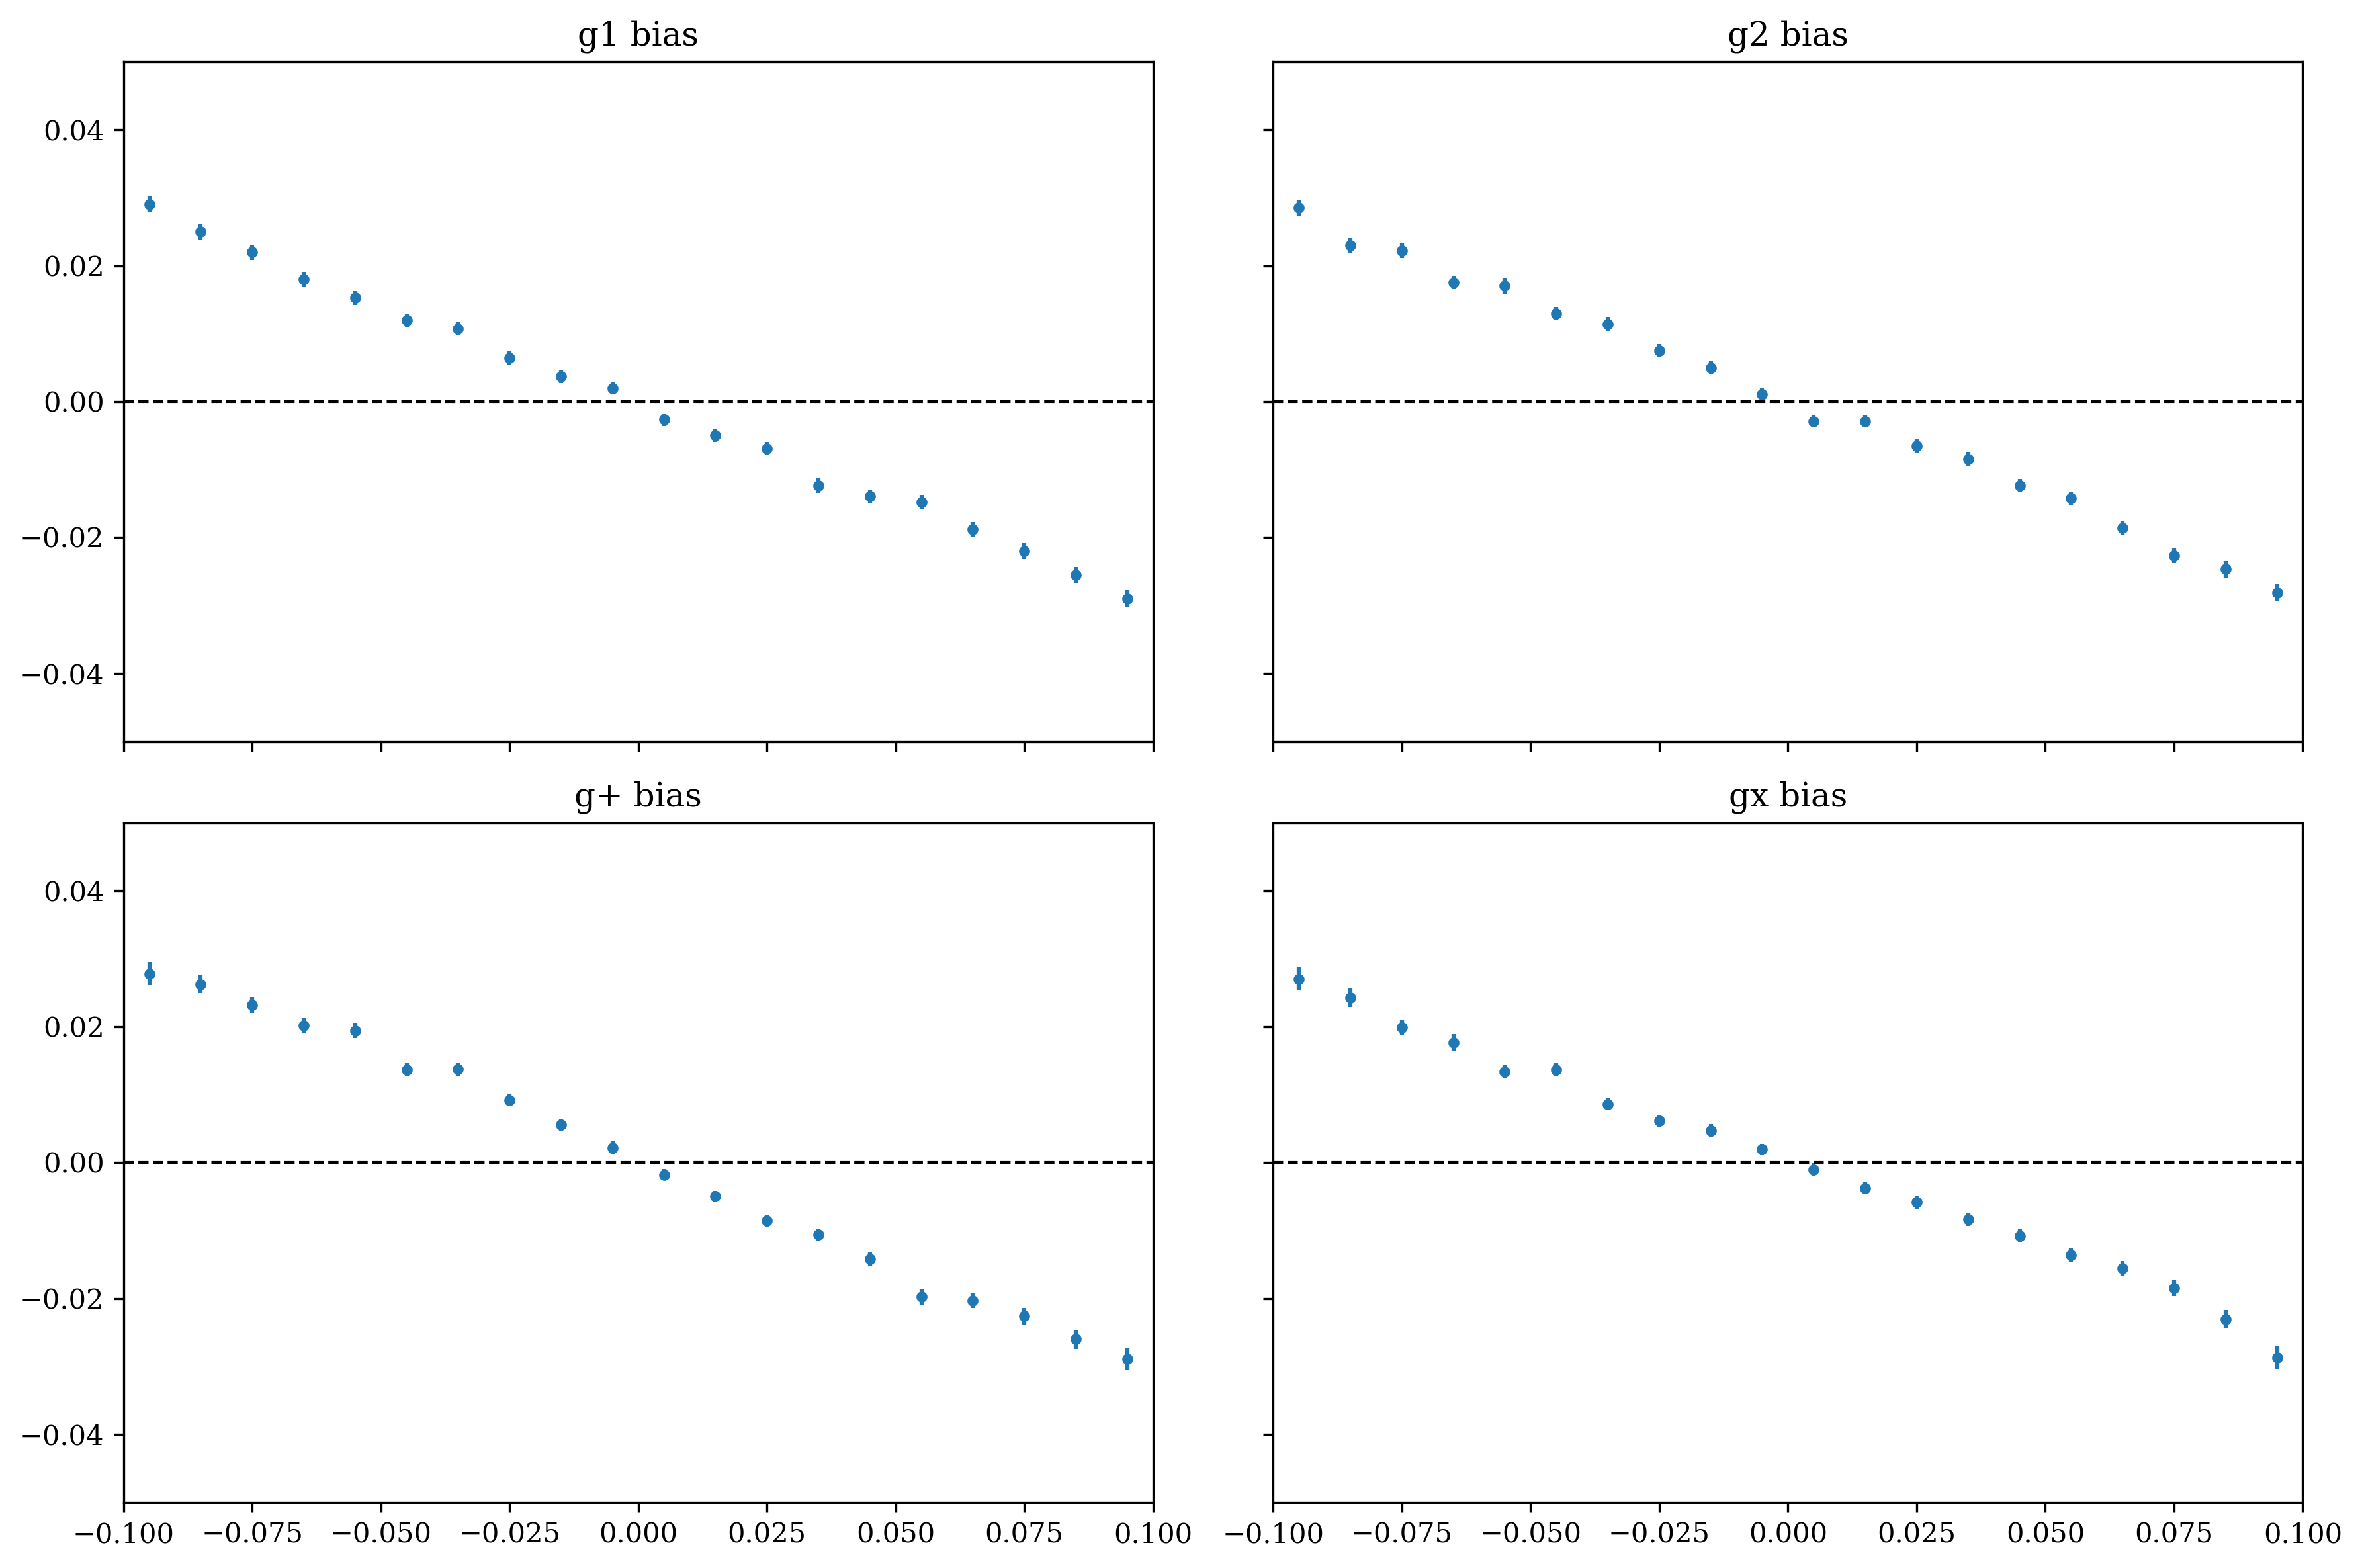

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

axes[0, 0].errorbar(c1, m1, yerr=e1, fmt='o', ms=3)
axes[0, 0].axhline(0.0, ls='--', c='k', lw=1)
axes[0, 0].set_title('g1 bias')

axes[0, 1].errorbar(c2, m2, yerr=e2, fmt='o', ms=3)
axes[0, 1].axhline(0.0, ls='--', c='k', lw=1)
axes[0, 1].set_title('g2 bias')

axes[1, 0].errorbar(cp, mp, yerr=ep, fmt='o', ms=3)
axes[1, 0].axhline(0.0, ls='--', c='k', lw=1)
axes[1, 0].set_title('g+ bias')

axes[1, 1].errorbar(cx, mx, yerr=ex, fmt='o', ms=3)
axes[1, 1].axhline(0.0, ls='--', c='k', lw=1)
axes[1, 1].set_title('gx bias')

for ax in axes.ravel():
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(-0.05, 0.05)

plt.tight_layout()
plt.savefig(join(fig_root, model_name, f'bias_summary_{mode_index}.png'), dpi=300)
plt.show()

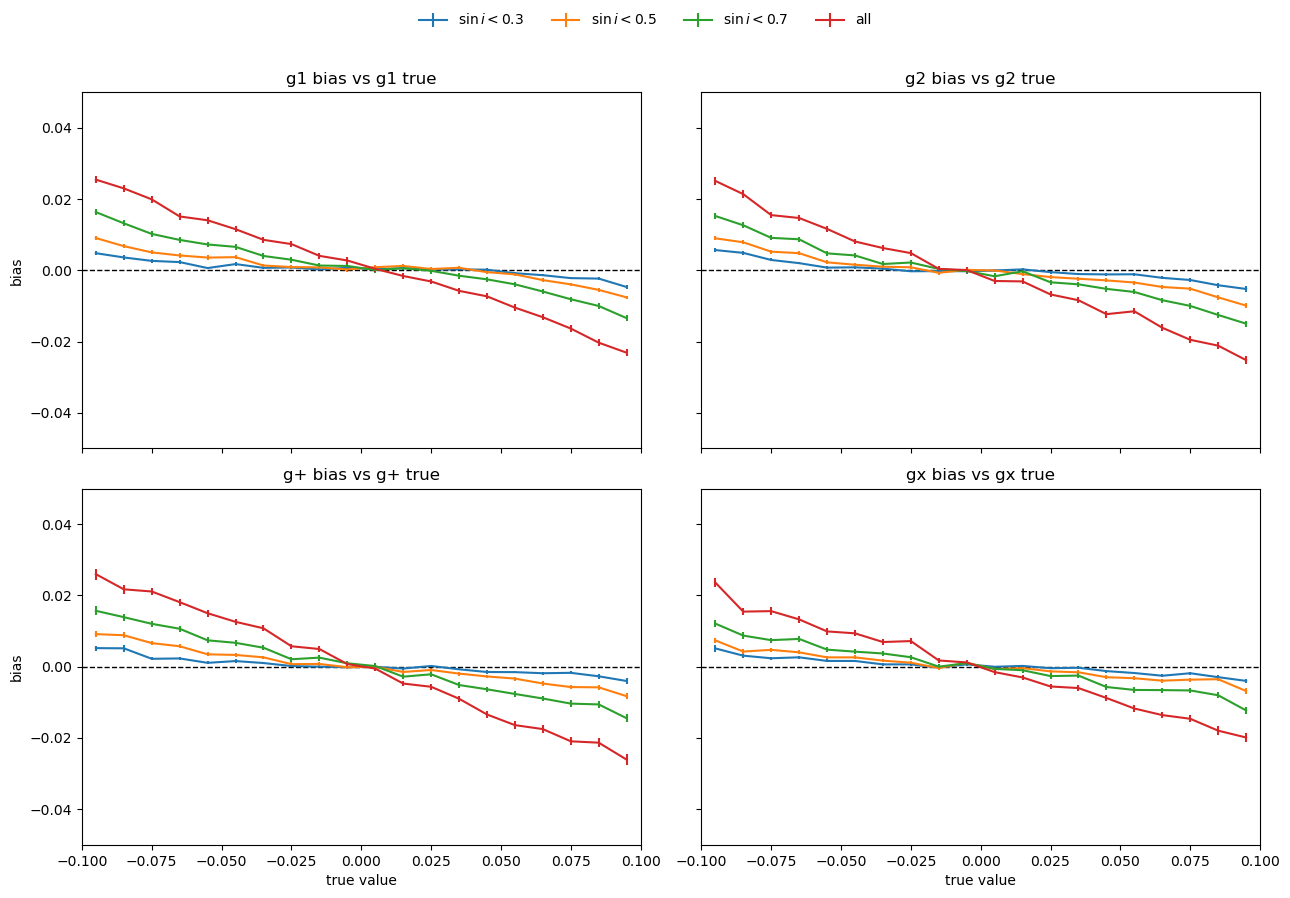

In [29]:
sini_cuts = [0.3, 0.5, 0.7, 1.0]
labels = [r'$\sin i < 0.3$', r'$\sin i < 0.5$', r'$\sin i < 0.7$', 'all']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

def binned_bias_masked(x_true, x_diff, mask, nbins=20):
    edges = np.linspace(-0.1, 0.1, nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    which = np.searchsorted(edges, x_true) - 1

    mean = np.full(nbins, np.nan, dtype=np.float64)
    err = np.full(nbins, np.nan, dtype=np.float64)

    for i in range(nbins):
        sel = (which == i) & mask
        if np.any(sel):
            vals = x_diff[sel]
            mean[i] = np.mean(vals)
            err[i] = np.std(vals) / np.sqrt(vals.shape[0])
    return centers, mean, err

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for cut, label, color in zip(sini_cuts, labels, colors):
    if cut >= 1.0:
        mask = np.ones_like(sini, dtype=bool)
    else:
        mask = sini < cut

    c1, m1, e1 = binned_bias_masked(g1_true, g1_diff, mask)
    c2, m2, e2 = binned_bias_masked(g2_true, g2_diff, mask)
    cp, mp, ep = binned_bias_masked(gp_true, gp_diff, mask)
    cx, mx, ex = binned_bias_masked(gc_true, gc_diff, mask)

    axes[0, 0].errorbar(c1, m1, yerr=e1, lw=1.5, color=color, label=label)
    axes[0, 1].errorbar(c2, m2, yerr=e2, lw=1.5, color=color, label=label)
    axes[1, 0].errorbar(cp, mp, yerr=ep, lw=1.5, color=color, label=label)
    axes[1, 1].errorbar(cx, mx, yerr=ex, lw=1.5, color=color, label=label)

axes[0, 0].set_title('g1 bias vs g1 true')
axes[0, 1].set_title('g2 bias vs g2 true')
axes[1, 0].set_title('g+ bias vs g+ true')
axes[1, 1].set_title('gx bias vs gx true')

for ax in axes.ravel():
    ax.axhline(0.0, ls='--', c='k', lw=1)
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(-0.05, 0.05)

axes[1, 0].set_xlabel('true value')
axes[1, 1].set_xlabel('true value')
axes[0, 0].set_ylabel('bias')
axes[1, 0].set_ylabel('bias')

handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', ncol=4, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(join(fig_root, model_name, f'bias_vs_true_sini_cuts_{mode_index}.png'), dpi=300)
plt.show()